In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
from scipy.signal import savgol_filter

import pathlib
import sys
project_root = pathlib.Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling import sim_func, sim_prf, model_fit

In [10]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_08_22_data_full_RDXrolling_timeseries.csv')
df = pd.read_csv(x).drop(columns=['Unnamed: 0', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)'])
df

,condition_id,condition,category,valence,time,RDX_rolling,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_grad
0,ACP_10,ACP,objet,negative,0.000000,-1.557942,-44.339866,329.0,-12.022054,1655.0,0.015888
1,ACP_10,ACP,objet,negative,0.003335,-1.235209,-44.339866,329.0,-12.022054,1655.0,0.015888
2,ACP_10,ACP,objet,negative,0.006670,-0.895758,-44.339866,329.0,-12.022054,1655.0,0.015888
3,ACP_10,ACP,objet,negative,0.010006,-0.548230,-44.339866,329.0,-12.022054,1655.0,0.015888
4,ACP_10,ACP,objet,negative,0.013341,-0.203163,-44.339866,329.0,-12.022054,1655.0,0.015888
...,...,...,...,...,...,...,...,...,...,...,...
795643,DFT_9,DFT,visage,positive,5.959993,-23.149807,-48.965409,317.0,-13.618955,1256.0,0.028713
795644,DFT_9,DFT,visage,positive,5.963328,-23.152393,-48.965409,317.0,-13.618955,1256.0,0.028713
795645,DFT_9,DFT,visage,positive,5.966663,-23.182579,-48.965409,317.0,-13.618955,1256.0,0.028713
795646,DFT_9,DFT,visage,positive,5.969998,-23.244083,-48.965409,317.0,-13.618955,1256.0,0.028713


In [12]:
weight = np.repeat([1.0, 0.4], [300, 1492])

curve_fitting = df.loc[:, ['condition_id', 'condition', 'category', 'valence', 'time', 'RDX_rolling']]

curve_fitting['fit_timeseries'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: model_fit(1792, x, weight)[1]
)

In [13]:
y = df[(df.condition_id=='DFT_6') & (df.category=='objet') & (df.valence=='neutre')]['RDX_rolling']
t = np.linspace(0, len(y), len(y))
values, fit = model_fit(len(y), y, np.repeat([1.0, 0.4], [300, 1492]))
print(values)

# plt.plot(fit)
# plt.plot(t, y)
# plt.tight_layout()

{'D_0': 0.1466964394773951, 'D_1': 6.578368201573485, 't_0': 96.96511938229952, 'tau_1': 19.842823050200302, 'tau_2': 412.58960756641994}


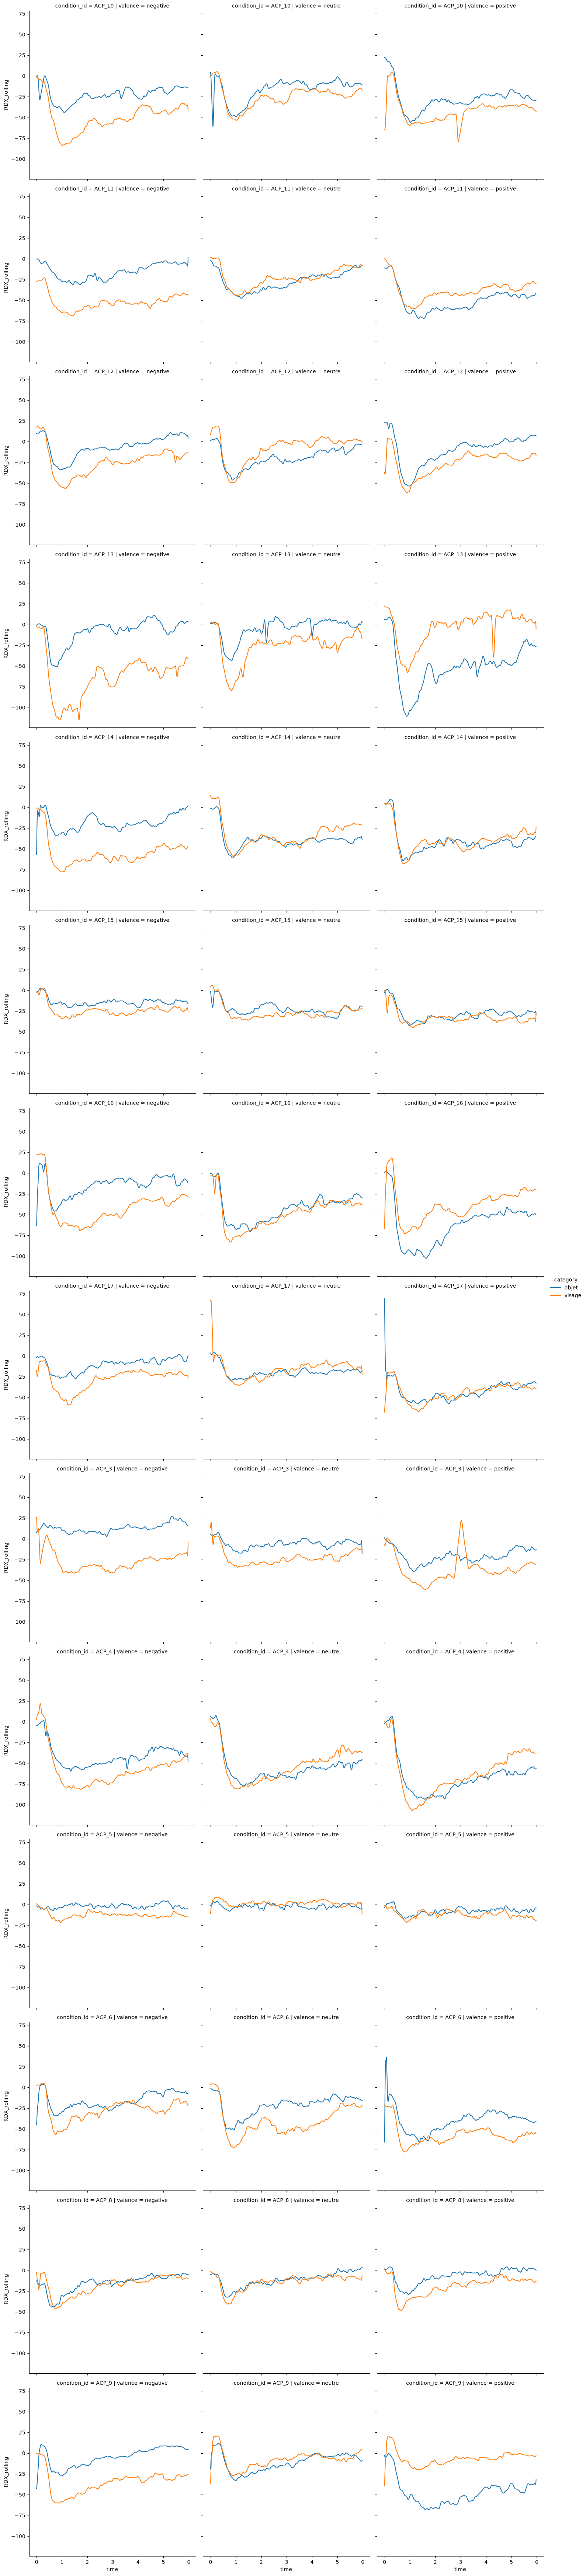

In [18]:
sns.relplot(df[df.condition=='ACP'], x='time', y='RDX_rolling', hue='category', col='valence', row='condition_id', kind='line', errorbar=None)

In [14]:
curve_fitting

,condition_id,condition,category,valence,time,RDX_rolling,fit_timeseries
0,ACP_10,ACP,objet,negative,0.000000,-1.557942,-13.526197
1,ACP_10,ACP,objet,negative,0.003335,-1.235209,-13.526197
2,ACP_10,ACP,objet,negative,0.006670,-0.895758,-13.526197
3,ACP_10,ACP,objet,negative,0.010006,-0.548230,-13.526197
4,ACP_10,ACP,objet,negative,0.013341,-0.203163,-13.526197
...,...,...,...,...,...,...,...
795643,DFT_9,DFT,visage,positive,5.959993,-23.149807,-10.274026
795644,DFT_9,DFT,visage,positive,5.963328,-23.152393,-10.273057
795645,DFT_9,DFT,visage,positive,5.966663,-23.182579,-10.272092
795646,DFT_9,DFT,visage,positive,5.969998,-23.244083,-10.271130


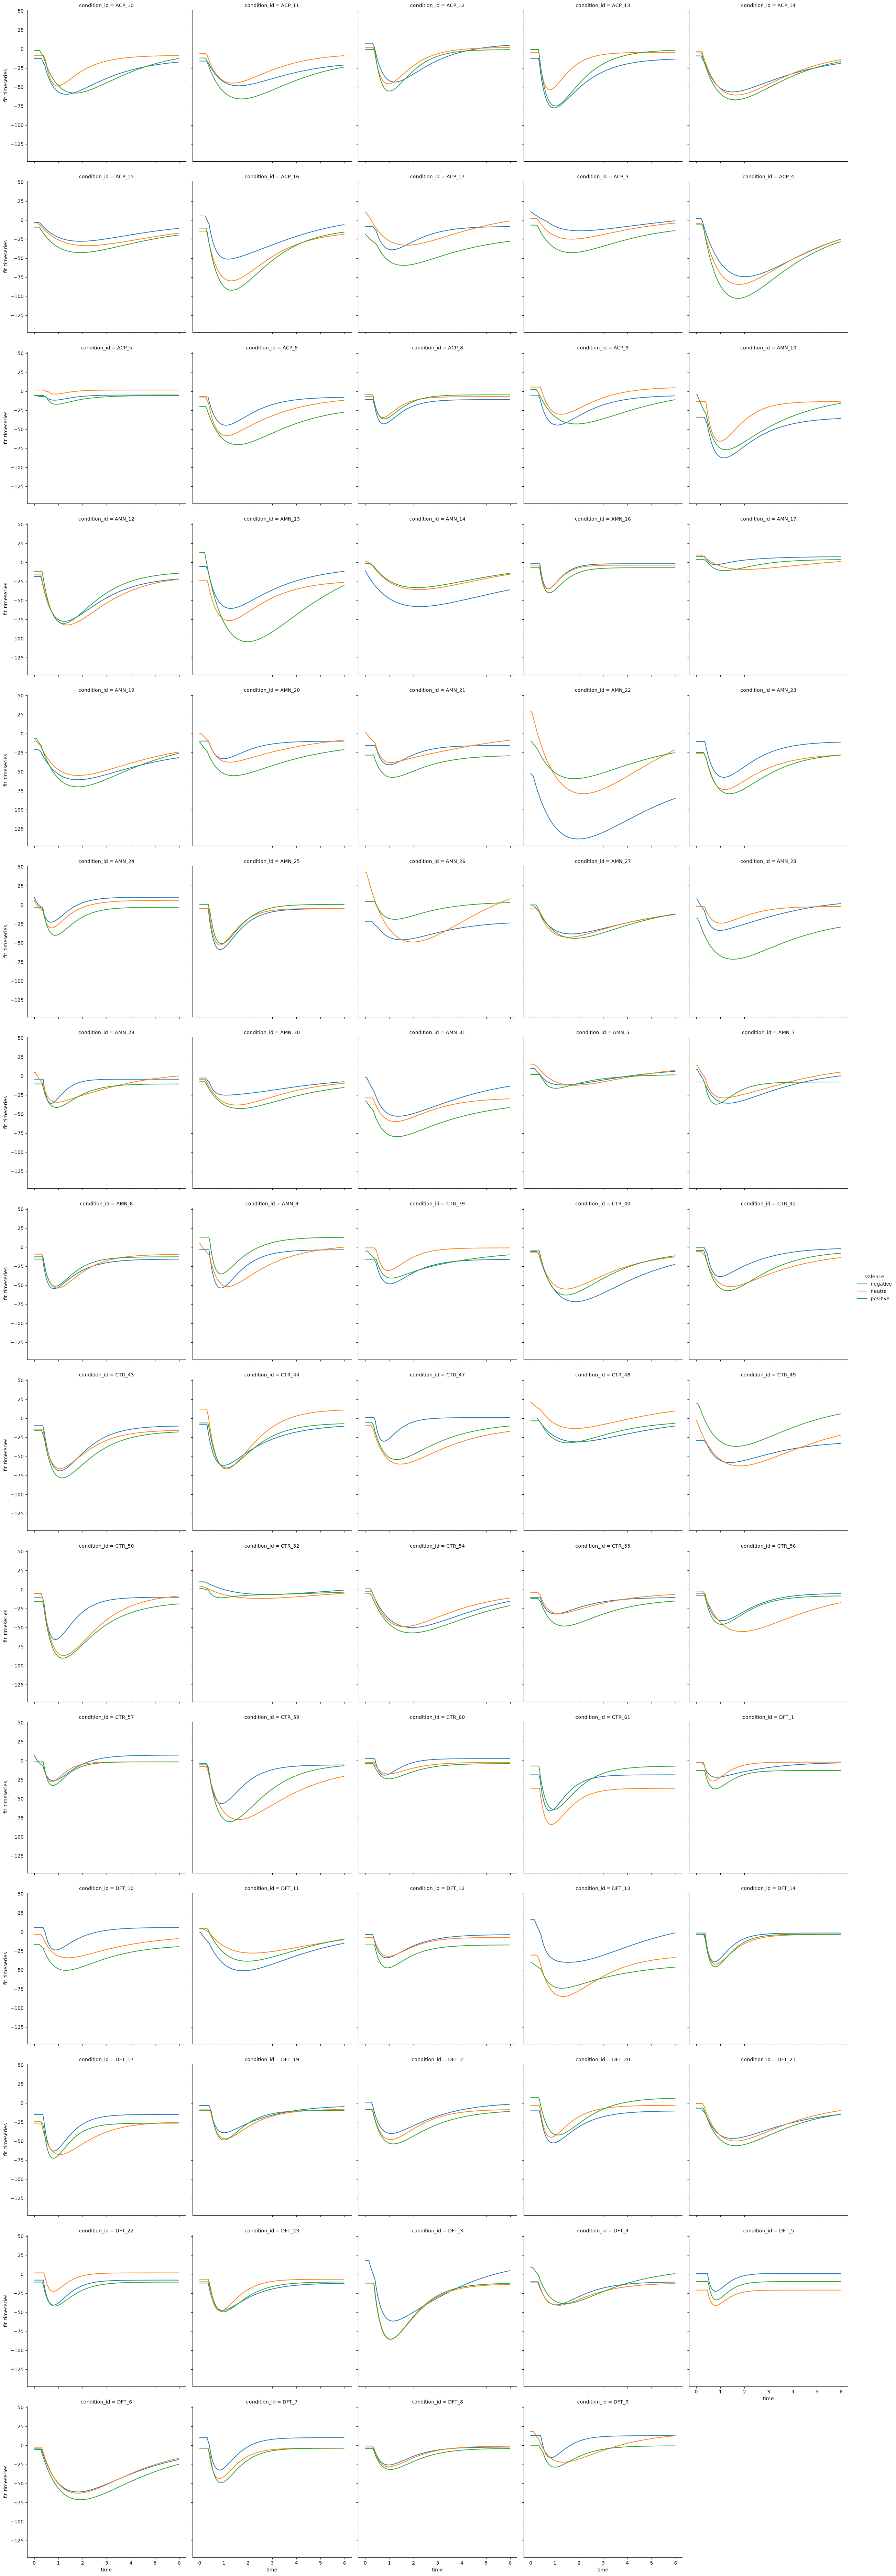

In [17]:
sns.relplot(curve_fitting, x='time', y='fit_timeseries', hue='valence', col='condition_id', col_wrap=5, kind='line', errorbar=None)

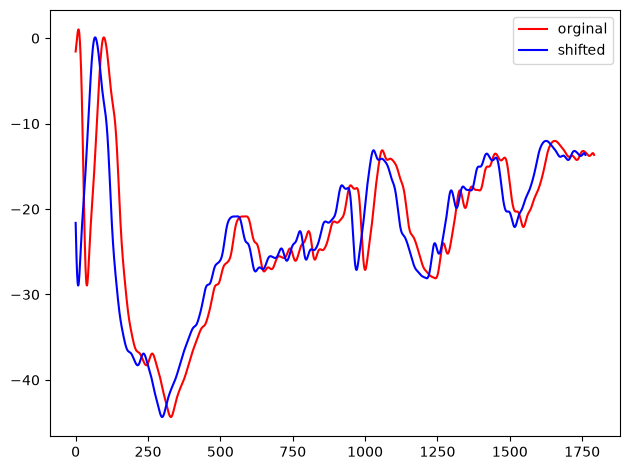

In [36]:
timeseries = df['RDX_rolling'].iloc[1792*0:1792*1]

plt.plot(timeseries, c='r', label='orginal')
plt.plot(timeseries.shift(-30), c='b', label='shifted')

plt.legend()
plt.tight_layout()
plt.show()

In [51]:
df['RDX_shifted'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
    lambda x: x - x.shift(-30)
)

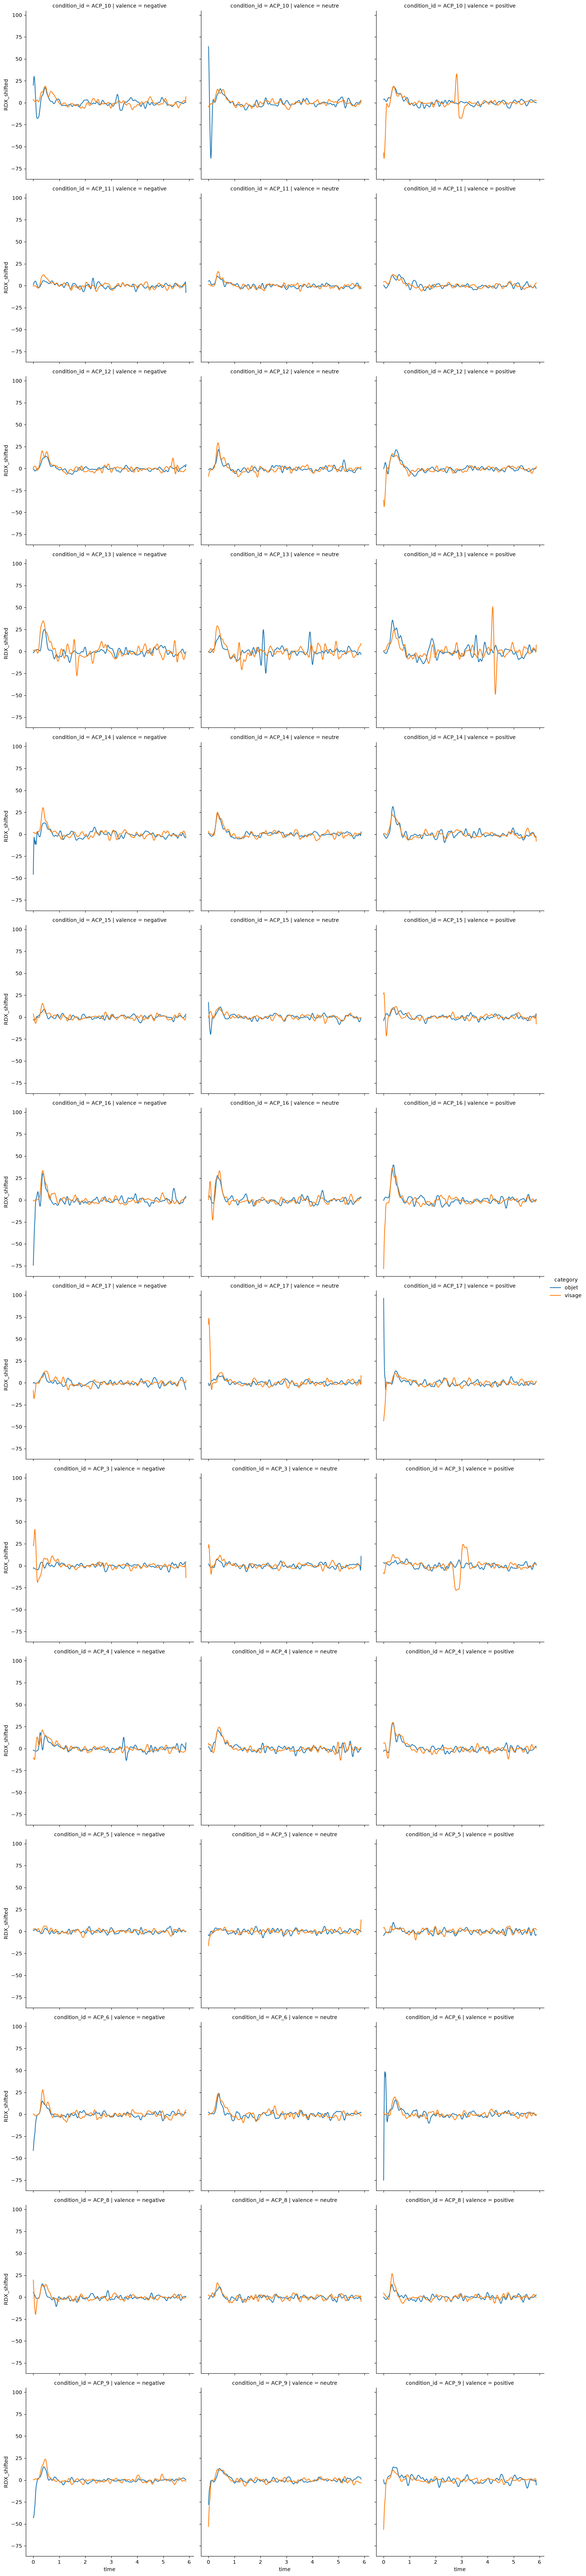

In [52]:
sns.relplot(df[df.condition=='ACP'], x='time', y='RDX_shifted', hue='category', col='valence', row='condition_id', kind='line', errorbar=None)

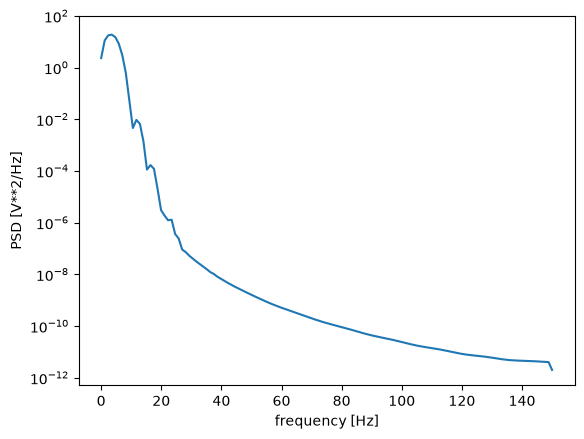

In [155]:
import scipy.signal as signal

x = np.array(df['RDX_shifted'][(df.condition_id=='ACP_13') & (df.valence=='positive') & (df.category=='visage')].dropna())
fs=300

f, Pxx_den = signal.welch(x, fs)
plt.semilogy(f, Pxx_den)
plt.ylim([0.5e-12, 1e+2])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

In [119]:
f[Pxx_den.argmax()]

np.float64(3.515625)

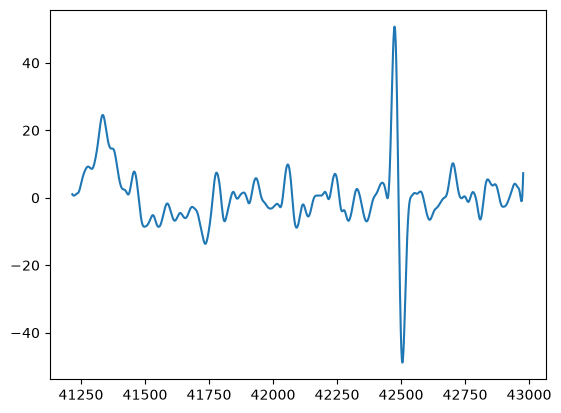

In [99]:
plt.plot(df['RDX_shifted'][(df.condition_id=='ACP_13') & (df.valence=='positive') & (df.category=='visage')].dropna())